## Header

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = os.path.join("data","cleaned","final_dataset.csv") 
df=pd.read_csv(path)


In [3]:
df1=pd.read_csv(path)

In [4]:
df.columns

Index(['order_id', 'order_date', 'order_year', 'order_month', 'order_day',
       'order_hour', 'order_minute', 'order_second', 'is_weekend',
       'order_status', 'customer_id', 'customer_name', 'gender', 'age',
       'customer_segment', 'country', 'city', 'customer_loyalty_score',
       'total_orders_by_customer', 'account_creation_date', 'product_id',
       'product_name', 'category', 'sub_category', 'brand',
       'product_rating_avg', 'product_reviews_count', 'stock_quantity',
       'unit_price_usd', 'quantity', 'discount_percent', 'total_price_usd',
       'cost_usd', 'profit_usd', 'tax_usd', 'payment_method', 'payment_status',
       'installment_plan', 'shipping_method', 'shipping_cost_usd',
       'delivery_days', 'shipping_country', 'warehouse_location',
       'delivery_status', 'device_type'],
      dtype='str')

## Order & Customer

In [5]:
temp=['order_id', 'order_date', 'order_year', 'order_month', 'order_day',
       'order_hour', 'order_minute', 'order_second', 'is_weekend',
       'order_status', 'customer_id', 'customer_name',
       'gender', 'age', 'customer_segment', 'country', 'city',
       'customer_loyalty_score', 'total_orders_by_customer',
       'account_creation_date',]
len(temp)

20

In [6]:
assigned_cols=['order_id','order_date','order_status','is_weekend',
               'customer_id','customer_name','gender','age','customer_segment',
               'country','city','customer_loyalty_score','total_orders_by_customer',
               'account_creation_date']

In [7]:
df=df[assigned_cols]

In [8]:
df.head()

,order_id,order_date,order_status,is_weekend,customer_id,customer_name,gender,age,customer_segment,country,city,customer_loyalty_score,total_orders_by_customer,account_creation_date
0,ORD-XAJI00,2024-10-14 11:20:05.496679,Completed,No,CUS-6DPBH0,Drew Warren,Male,53,Regular,Netherlands,Utrecht,22.0,38,2022-04-23
1,ORD-NHJ7X0,2024-10-21 00:49:44.681065,Completed,No,CUS-G0FN90,Victor Sullivan,Male,61,Regular,United States,Los Angeles,82.2,21,2022-08-22
2,ORD-YTJXE0,2025-03-17 19:49:36.983317,Completed,No,CUS-Q85JS0,Jason Garcia,Male,50,VIP,France,Nice,60.9,10,2024-08-04
3,ORD-EIMVI0,2024-09-27 06:24:44.913768,Completed,No,CUS-CWI640,David Norris,Male,50,Regular,Italy,Milan,53.9,47,2023-08-06
4,ORD-OR56F0,2025-05-21 17:10:48.401882,Completed,No,CUS-O72KZ0,Laura Phillips,Female,27,Regular,Germany,Berlin,57.9,35,2023-01-02


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000123 entries, 0 to 1000122
Data columns (total 14 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   order_id                  1000123 non-null  str    
 1   order_date                1000123 non-null  str    
 2   order_status              1000123 non-null  str    
 3   is_weekend                1000123 non-null  str    
 4   customer_id               1000123 non-null  str    
 5   customer_name             1000123 non-null  str    
 6   gender                    1000123 non-null  str    
 7   age                       1000123 non-null  int64  
 8   customer_segment          1000123 non-null  str    
 9   country                   1000123 non-null  str    
 10  city                      1000123 non-null  str    
 11  customer_loyalty_score    1000123 non-null  float64
 12  total_orders_by_customer  1000123 non-null  int64  
 13  account_creation_date     1000123 non-

In [10]:
df.loc[df['order_id'].duplicated(False)].sort_values(by='order_id').head(10)

,order_id,order_date,order_status,is_weekend,customer_id,customer_name,gender,age,customer_segment,country,city,customer_loyalty_score,total_orders_by_customer,account_creation_date


In [11]:
df.loc[df['customer_id'].duplicated(False)].sort_values(by='customer_id').head(10)

,order_id,order_date,order_status,is_weekend,customer_id,customer_name,gender,age,customer_segment,country,city,customer_loyalty_score,total_orders_by_customer,account_creation_date
358556,ORD-DB8P10,2025-11-05 00:49:50.341831,Completed,No,CUS-O97X40,Christina Moore,Female,50,Premium,France,Lyon,70.7,15,2024-12-05
931891,ORD-W8HC70,2024-10-07 14:01:08.804220,Completed,No,CUS-O97X40,Christina Moore,Female,24,Regular,France,Nice,13.7,47,2023-07-20


In [12]:
df['customer_name'].nunique()

330156

In [13]:
df[['customer_id','customer_name']].groupby('customer_name').count()

,customer_id
customer_name,
Aaron Abbott,4
Aaron Acevedo,2
Aaron Acosta,1
Aaron Acosta MD,1
Aaron Adams,12
...,...
Zoe Wilson,4
Zoe Winters,1
Zoe Wright,2


In [14]:
df[df['customer_name']=='Aaron Adams']

,order_id,order_date,order_status,is_weekend,customer_id,customer_name,gender,age,customer_segment,country,city,customer_loyalty_score,total_orders_by_customer,account_creation_date
56257,ORD-DJGZM0,2025-02-02 13:16:32.666007,Completed,Yes,CUS-7VHQ90,Aaron Adams,Male,37,Premium,United Kingdom,Leeds,90.6,44,2023-06-30
111915,ORD-ZB5X00,2025-04-14 06:55:58.424017,Pending,No,CUS-H7L6V0,Aaron Adams,Male,42,Premium,Germany,Hamburg,67.0,11,2023-09-27
276981,ORD-F4WWJ0,2025-11-09 01:50:29.427604,Pending,Yes,CUS-NKN1W0,Aaron Adams,Male,34,Regular,Canada,Vancouver,1.1,39,2025-02-04
301828,ORD-39DC30,2025-10-19 13:49:11.883083,Cancelled,Yes,CUS-25O3U0,Aaron Adams,Male,21,Premium,United Kingdom,Manchester,86.2,30,2025-05-11
309763,ORD-C4C2K0,2025-07-04 08:21:59.356142,Returned,No,CUS-QCYQO0,Aaron Adams,Male,31,Regular,Australia,Sydney,12.3,29,2021-05-07
396789,ORD-Z0EOC0,2024-08-22 15:10:46.724032,Completed,No,CUS-O8A9B0,Aaron Adams,Male,27,Regular,Spain,Barcelona,90.0,12,2023-03-30
632688,ORD-XRCDQ0,2025-03-02 23:05:11.418470,Completed,Yes,CUS-H66EV0,Aaron Adams,Male,40,Regular,France,Marseille,68.6,28,2022-03-26
670733,ORD-9R4H30,2025-07-24 04:34:40.718323,Completed,No,CUS-NPF8I0,Aaron Adams,Male,33,Premium,Canada,Calgary,8.8,23,2025-02-16
756344,ORD-PMWP80,2026-01-26 01:35:14.251919,Completed,No,CUS-725O60,Aaron Adams,Male,31,Regular,Italy,Naples,56.2,48,2022-10-19
775557,ORD-JKMU20,2025-09-19 19:40:28.115672,Cancelled,No,CUS-4KTQS0,Aaron Adams,Male,47,Regular,France,Marseille,63.5,27,2022-02-09


In [15]:
df.shape[0]

1000123

In [16]:
df['order_date']=pd.to_datetime(df['order_date'])

In [17]:
df['order_status'].unique()

<StringArray>
['Completed', 'Returned', 'Pending', 'Cancelled', 'Processing']
Length: 5, dtype: str

<Axes: xlabel='order_status'>

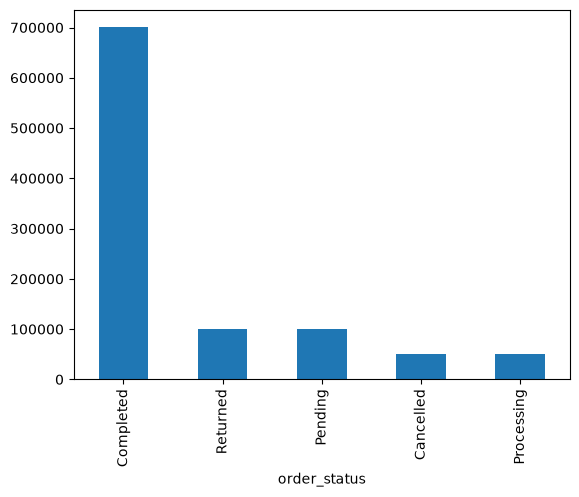

In [18]:
df['order_status'].value_counts().plot(kind='bar')

In [19]:
df['is_weekend'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

[Text(0, 3, '713021'), Text(0, 3, '287102')]

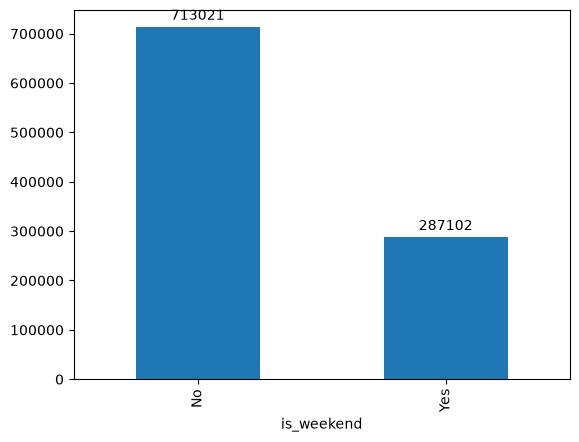

In [20]:
ax=df['is_weekend'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0], padding=3)

In [21]:
df['customer_name'].nunique()

330156

In [22]:
df['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

[Text(0, 3, '500180'), Text(0, 3, '499943')]

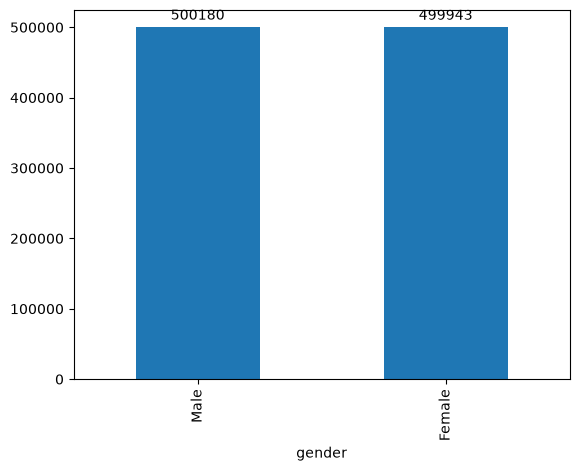

In [23]:
ax=df['gender'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0], padding=3)

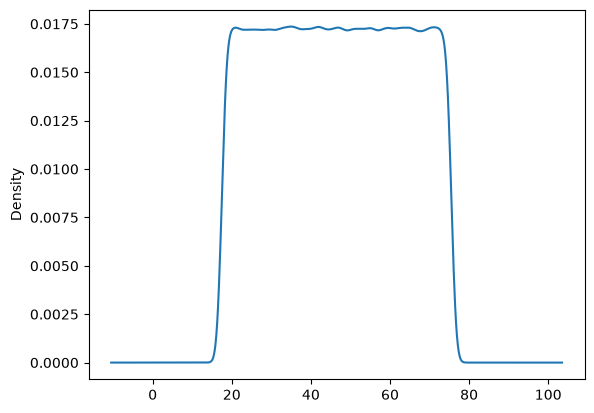

In [24]:
df['age'].plot(kind='kde')
plt.show()

In [25]:
df['customer_segment'].unique()

<StringArray>
['Regular', 'VIP', 'Premium']
Length: 3, dtype: str

<Axes: xlabel='customer_segment'>

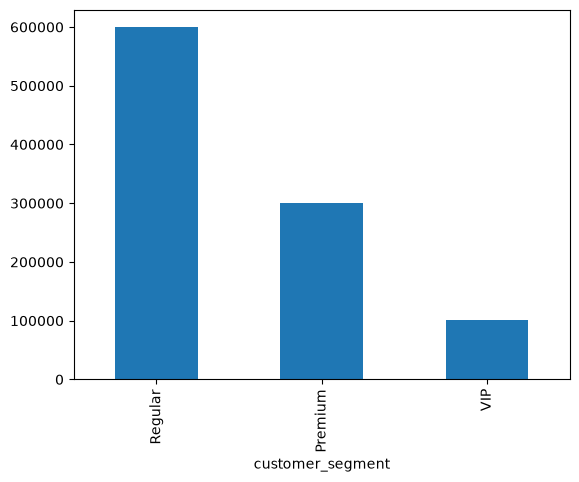

In [26]:
df['customer_segment'].value_counts().plot(kind='bar')

In [27]:
df['country'].unique()

<StringArray>
[   'Netherlands',  'United States',         'France',          'Italy',
        'Germany',         'Canada',      'Australia',        'Belgium',
 'United Kingdom',          'Spain']
Length: 10, dtype: str

[Text(0, 0, '100548'),
 Text(0, 0, '100357'),
 Text(0, 0, '100147'),
 Text(0, 0, '100064'),
 Text(0, 0, '100041'),
 Text(0, 0, '100023'),
 Text(0, 0, '99774'),
 Text(0, 0, '99761'),
 Text(0, 0, '99742'),
 Text(0, 0, '99666')]

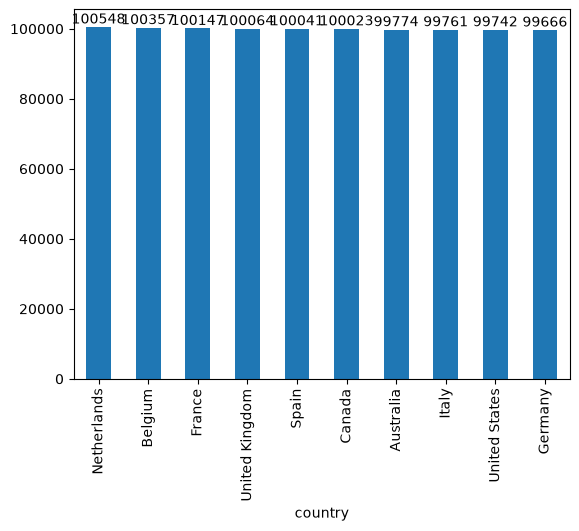

In [28]:
ax=df['country'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])

In [29]:
df['city'].nunique()

50

<Axes: xlabel='city'>

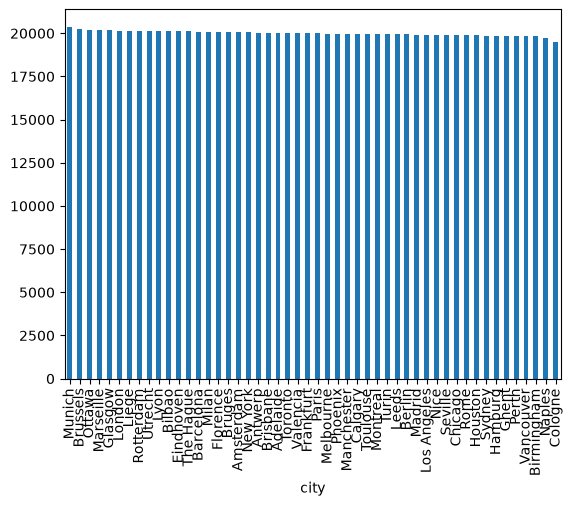

In [30]:
df['city'].value_counts().plot(kind='bar')

In [31]:
df['customer_loyalty_score'].describe()

count    1.000123e+06
mean     4.997252e+01
std      2.889377e+01
min      0.000000e+00
25%      2.490000e+01
50%      5.000000e+01
75%      7.500000e+01
max      1.000000e+02
Name: customer_loyalty_score, dtype: float64

<Axes: ylabel='Density'>

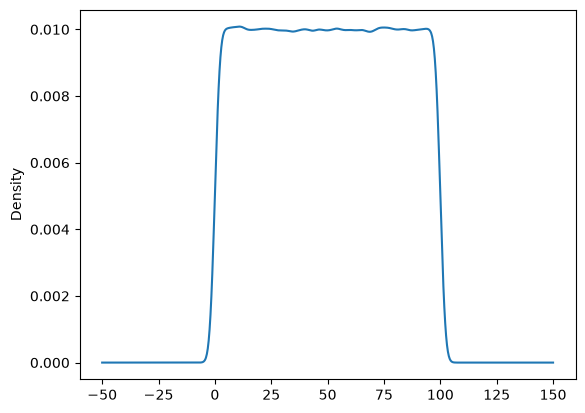

In [32]:
df['customer_loyalty_score'].plot(kind='kde')

In [33]:
df['total_orders_by_customer'].describe()

count    1.000123e+06
mean     2.548700e+01
std      1.443421e+01
min      1.000000e+00
25%      1.300000e+01
50%      2.500000e+01
75%      3.800000e+01
max      5.000000e+01
Name: total_orders_by_customer, dtype: float64

<Axes: ylabel='Density'>

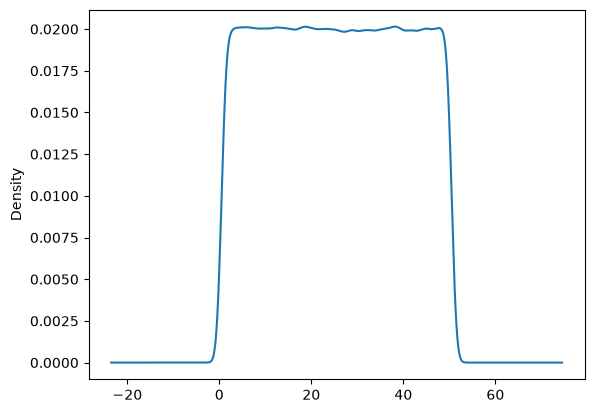

In [34]:
df['total_orders_by_customer'].plot(kind='kde')

In [35]:
df['account_creation_date'].nunique()

1826

In [36]:
df['account_creation_date']=pd.to_datetime(df['account_creation_date'])

<Axes: xlabel='order_date'>

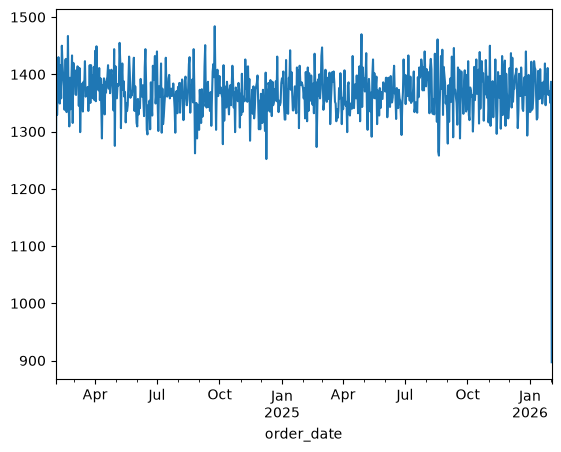

In [37]:
order_counts = df.groupby(df['order_date'].dt.to_period("D")).size()

order_counts.plot(kind='line')

In [38]:
df[['customer_id','customer_name']].groupby('customer_id').count()['customer_name'].unique()

array([1, 2])

In [39]:
df[['order_id','order_date']].groupby('order_id').count()['order_date'].unique()

array([1])

In [40]:
df1.columns

Index(['order_id', 'order_date', 'order_year', 'order_month', 'order_day',
       'order_hour', 'order_minute', 'order_second', 'is_weekend',
       'order_status', 'customer_id', 'customer_name', 'gender', 'age',
       'customer_segment', 'country', 'city', 'customer_loyalty_score',
       'total_orders_by_customer', 'account_creation_date', 'product_id',
       'product_name', 'category', 'sub_category', 'brand',
       'product_rating_avg', 'product_reviews_count', 'stock_quantity',
       'unit_price_usd', 'quantity', 'discount_percent', 'total_price_usd',
       'cost_usd', 'profit_usd', 'tax_usd', 'payment_method', 'payment_status',
       'installment_plan', 'shipping_method', 'shipping_cost_usd',
       'delivery_days', 'shipping_country', 'warehouse_location',
       'delivery_status', 'device_type'],
      dtype='str')

## cat & sub cat analysis 

In [41]:
print(df1['category'].unique())
df1['sub_category'].unique()

<StringArray>
['Home', 'Health', 'Sports', 'Electronics', 'Clothing']
Length: 5, dtype: str


<StringArray>
[        'Kitchen',     'Supplements',       'Furniture',     'Accessories',
         'Cameras',      'Appliances',         'Bedding',     'Smartphones',
   'Personal Care',         'Tablets',     'Sports Wear',     'Womens Wear',
           'Shoes',       'Mens Wear',           'Decor',   'Gym Equipment',
         'Fitness',         'Laptops',       'Kids Wear',         'Outdoor',
 'Medical Devices',           'Audio']
Length: 22, dtype: str

In [42]:
df1[['category','sub_category']].value_counts().sort_index()

category     sub_category   
Clothing     Accessories        39925
             Kids Wear          39789
             Mens Wear          39909
             Shoes              40036
             Womens Wear        39885
Electronics  Accessories        33294
             Audio              33340
             Cameras            33515
             Laptops            33232
             Smartphones        33265
             Tablets            33373
Health       Fitness            49567
             Medical Devices    49826
             Personal Care      50039
             Supplements        50142
Home         Appliances         39588
             Bedding            40105
             Decor              40507
             Furniture          40147
             Kitchen            40242
Sports       Accessories        50483
             Gym Equipment      50141
             Outdoor            49816
             Sports Wear        49957
Name: count, dtype: int64

In [43]:
home=['Kitchen', 'Furniture', 'Appliances', 'Bedding', 'Decor']
health= ['Supplements', 'Personal Care', 'Medical Devices']
sports= ['Gym Equipment', 'Fitness', 'Outdoor', 'Sports Wear']
Electronics= ['Cameras', 'Smartphones', 'Tablets', 'Laptops', 'Audio']
Clothing= ['Womens Wear', 'Mens Wear', 'Kids Wear', 'Shoes', 'Accessories']



In [44]:
print(len(df1[(df1['category'] == "Home") & (df1['sub_category'].isin(home))]))
print(len(df1[(df1['category'] == "Home") & (~df1['sub_category'].isin(home))]))


len(df1[(df1['category'] == "Home")])

200589
0


200589

In [45]:
cat = ['Home', 'Health', 'Sports', 'Electronics', 'Clothing']

sub_cat = {
    'Home': home,
    'Health': health,
    'Sports': sports,
    'Electronics': Electronics,
    'Clothing': Clothing
}

for i in cat:
    
    wrong = df1[
        (df1['category'] == i) &
        (~df1['sub_category'].isin(sub_cat[i]))
    ]
    
    print(i, "discrepancies:", len(wrong))
    print(wrong['sub_category'].value_counts())
    print()

Home discrepancies: 0
Series([], Name: count, dtype: int64)

Health discrepancies: 49567
sub_category
Fitness    49567
Name: count, dtype: int64

Sports discrepancies: 50483
sub_category
Accessories    50483
Name: count, dtype: int64

Electronics discrepancies: 33294
sub_category
Accessories    33294
Name: count, dtype: int64

Clothing discrepancies: 0
Series([], Name: count, dtype: int64)



In [46]:
cat = ['Home', 'Health', 'Sports', 'Electronics', 'Clothing']

sub_cat = {
    'Home': home,
    'Health': health,
    'Sports': sports,
    'Electronics': Electronics,
    'Clothing': Clothing
}

for i in cat:
    
    valid = len(df1[
        (df1['category'] == i) &
        (df1['sub_category'].isin(sub_cat[i]))
    ])
    
    invalid = len(df1[
        (df1['category'] == i) &
        (~df1['sub_category'].isin(sub_cat[i]))
    ])
    
    total = len(df1[df1['category'] == i])
    
    print(i)
    print("Valid:", valid)
    print("Invalid:", invalid)
    print("Total:", total)
    print()

Home
Valid: 200589
Invalid: 0
Total: 200589

Health
Valid: 150007
Invalid: 49567
Total: 199574

Sports
Valid: 149914
Invalid: 50483
Total: 200397

Electronics
Valid: 166725
Invalid: 33294
Total: 200019

Clothing
Valid: 199544
Invalid: 0
Total: 199544



In [47]:
for i in cat:
    
    wrong = df1[
        (df1['category'] == i) &
        (~df1['sub_category'].isin(sub_cat[i]))
    ]
    
    print("\n", i)
    print(wrong[['category', 'sub_category']])


 Home
Empty DataFrame
Columns: [category, sub_category]
Index: []

 Health
        category sub_category
23        Health      Fitness
36        Health      Fitness
70        Health      Fitness
106       Health      Fitness
129       Health      Fitness
...          ...          ...
1000046   Health      Fitness
1000048   Health      Fitness
1000053   Health      Fitness
1000061   Health      Fitness
1000120   Health      Fitness

[49567 rows x 2 columns]

 Sports
        category sub_category
3         Sports  Accessories
126       Sports  Accessories
128       Sports  Accessories
170       Sports  Accessories
250       Sports  Accessories
...          ...          ...
1000091   Sports  Accessories
1000100   Sports  Accessories
1000105   Sports  Accessories
1000108   Sports  Accessories
1000118   Sports  Accessories

[50483 rows x 2 columns]

 Electronics
            category sub_category
50       Electronics  Accessories
140      Electronics  Accessories
149      Electronics  Acces

In [48]:
for i in cat:
    
    wrong = df1[
        (df1['category'] == i) &
        (~df1['sub_category'].isin(sub_cat[i]))
    ]
    
    print("\n", i)
    print(wrong['sub_category'].value_counts())


 Home
Series([], Name: count, dtype: int64)

 Health
sub_category
Fitness    49567
Name: count, dtype: int64

 Sports
sub_category
Accessories    50483
Name: count, dtype: int64

 Electronics
sub_category
Accessories    33294
Name: count, dtype: int64

 Clothing
Series([], Name: count, dtype: int64)


In [49]:
for i in cat:
    
    wrong = df1[
        (df1['category'] == i) &
        (~df1['sub_category'].isin(sub_cat[i]))
    ]
    
    print("\n", i)
    display(wrong)
    


 Home


,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,...,payment_method,payment_status,installment_plan,shipping_method,shipping_cost_usd,delivery_days,shipping_country,warehouse_location,delivery_status,device_type



 Health


,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,...,payment_method,payment_status,installment_plan,shipping_method,shipping_cost_usd,delivery_days,shipping_country,warehouse_location,delivery_status,device_type
23,ORD-MDYVS0,2024-10-28 22:51:38.557816,2024,10,28,22,51,38,No,Completed,...,Bank Transfer,Paid,No,Next Day,2.88,1,Australia,EU-Central,Delivered,Desktop
36,ORD-EWVIY0,2024-10-07 16:38:12.614625,2024,10,7,16,38,12,No,Completed,...,Bank Transfer,Paid,Yes,Express,23.42,14,Canada,EU-Central,In Transit,Tablet
70,ORD-A5S000,2024-12-29 11:31:00.469026,2024,12,29,11,31,0,Yes,Completed,...,Apple Pay,Paid,No,Economy,10.08,4,Italy,USA-East,Delivered,Tablet
106,ORD-YV3LX0,2025-03-27 01:46:06.253117,2025,3,27,1,46,6,No,Completed,...,Debit Card,Paid,No,Next Day,22.53,1,Netherlands,USA-East,Delivered,Mobile
129,ORD-B2JTX0,2024-06-21 23:03:05.972731,2024,6,21,23,3,5,No,Completed,...,PayPal,Paid,Yes,Express,3.61,3,Spain,USA-West,Failed,Mobile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000046,ORD-JGAPJ0,2025-10-06 07:28:27.958109,2025,10,6,7,28,27,No,Returned,...,Bank Transfer,Paid,No,Standard,22.93,14,Canada,USA-East,Failed,Desktop
1000048,ORD-KKHBG0,2025-09-01 16:08:51.336731,2025,9,1,16,8,51,No,Completed,...,PayPal,Paid,No,Economy,21.30,14,Germany,USA-East,Failed,Mobile
1000053,ORD-44NYT0,2025-02-26 23:28:50.131622,2025,2,26,23,28,50,No,Completed,...,Debit Card,Paid,Yes,Standard,18.13,10,France,USA-East,Delivered,Mobile
1000061,ORD-QQS0G0,2025-11-03 14:37:52.614143,2025,11,3,14,37,52,No,Completed,...,Apple Pay,Paid,Yes,Next Day,19.35,14,Spain,Asia-Pacific,Delivered,Desktop



 Sports


,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,...,payment_method,payment_status,installment_plan,shipping_method,shipping_cost_usd,delivery_days,shipping_country,warehouse_location,delivery_status,device_type
3,ORD-EIMVI0,2024-09-27 06:24:44.913768,2024,9,27,6,24,44,No,Completed,...,Credit Card,Paid,No,Express,4.76,8,Italy,USA-West,Delivered,Mobile
126,ORD-Q4PBG0,2025-09-24 07:23:01.494564,2025,9,24,7,23,1,No,Completed,...,Debit Card,Paid,Yes,Standard,19.13,11,Belgium,EU-Central,Delivered,Desktop
128,ORD-SKXLO0,2026-01-12 22:12:53.012619,2026,1,12,22,12,53,No,Completed,...,Bank Transfer,Paid,Yes,Next Day,16.15,5,Italy,UK,Delivered,Desktop
170,ORD-YOLD60,2026-01-14 05:17:12.560864,2026,1,14,5,17,12,No,Pending,...,Apple Pay,Failed,Yes,Economy,14.81,5,United Kingdom,USA-East,Delivered,Tablet
250,ORD-6UZS10,2025-08-13 15:29:17.031274,2025,8,13,15,29,17,No,Completed,...,Debit Card,Paid,No,Standard,1.18,5,Italy,Asia-Pacific,Delivered,Tablet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000091,ORD-VHEDV0,2024-11-05 12:05:32.528072,2024,11,5,12,5,32,No,Processing,...,Apple Pay,Paid,No,Express,8.13,13,Italy,EU-Central,Delivered,Mobile
1000100,ORD-AKRGX0,2024-03-03 04:27:40.071003,2024,3,3,4,27,40,Yes,Completed,...,Bank Transfer,Paid,No,Economy,24.36,12,United States,Asia-Pacific,In Transit,Tablet
1000105,ORD-CHTXM0,2024-08-28 04:42:15.554907,2024,8,28,4,42,15,No,Completed,...,Credit Card,Paid,No,Standard,21.07,13,Belgium,USA-East,Failed,Desktop
1000108,ORD-QEFYU0,2025-04-23 13:52:43.847353,2025,4,23,13,52,43,No,Completed,...,Debit Card,Paid,No,Next Day,2.96,13,United States,USA-West,In Transit,Mobile



 Electronics


,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,...,payment_method,payment_status,installment_plan,shipping_method,shipping_cost_usd,delivery_days,shipping_country,warehouse_location,delivery_status,device_type
50,ORD-E1OCJ0,2025-03-10 05:16:36.302780,2025,3,10,5,16,36,No,Completed,...,Bank Transfer,Paid,No,Economy,6.71,14,France,EU-Central,Delivered,Tablet
140,ORD-KGJZO0,2024-10-20 22:19:15.778872,2024,10,20,22,19,15,Yes,Completed,...,Credit Card,Paid,No,Next Day,10.48,11,Italy,UK,In Transit,Tablet
149,ORD-CYUKN0,2024-11-04 21:56:34.400085,2024,11,4,21,56,34,No,Completed,...,Bank Transfer,Paid,No,Express,3.44,1,Belgium,USA-East,Delivered,Tablet
168,ORD-AUUJ00,2025-08-02 15:15:49.839181,2025,8,2,15,15,49,Yes,Pending,...,Apple Pay,Pending,Yes,Standard,0.98,10,Netherlands,USA-West,Delivered,Mobile
277,ORD-UMAPQ0,2025-09-22 01:26:44.998697,2025,9,22,1,26,44,No,Completed,...,Debit Card,Paid,No,Express,10.24,3,Belgium,UK,Delivered,Mobile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999925,ORD-YCSRT0,2025-01-17 21:13:08.898993,2025,1,17,21,13,8,No,Returned,...,Apple Pay,Paid,No,Express,16.20,2,United Kingdom,EU-Central,Delivered,Tablet
999932,ORD-LQP120,2025-01-13 07:59:14.941854,2025,1,13,7,59,14,No,Completed,...,Credit Card,Paid,No,Economy,7.51,4,Canada,EU-Central,In Transit,Tablet
999960,ORD-K84RS0,2024-02-04 15:32:47.766222,2024,2,4,15,32,47,Yes,Completed,...,Bank Transfer,Paid,Yes,Express,4.29,1,Germany,Asia-Pacific,Delivered,Tablet
1000006,ORD-51PFT0,2024-04-08 10:25:31.991615,2024,4,8,10,25,31,No,Returned,...,PayPal,Paid,No,Standard,6.78,1,Netherlands,USA-West,In Transit,Mobile



 Clothing


,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,...,payment_method,payment_status,installment_plan,shipping_method,shipping_cost_usd,delivery_days,shipping_country,warehouse_location,delivery_status,device_type


In [50]:
df2 = df1[['shipping_method', 'shipping_cost_usd',
       'delivery_days', 'shipping_country', 'warehouse_location',
       'delivery_status']]
df2.head()cat = ['Home', 'Health', 'Sports', 'Electronics', 'Clothing']

sub_cat = {
    'Home': home,
    'Health': health,
    'Sports': sports,
    'Electronics': Electronics,
    'Clothing': Clothing
}

discrepancies = []

for i in cat:
    wrong = df1[
        (df1['category'] == i) &
        (~df1['sub_category'].isin(sub_cat[i]))
    ]
    
    discrepancies.append(wrong)

discrepancies = pd.concat(discrepancies)

print(len(discrepancies))
print(len(df1))
(1-((len(df1)-len(discrepancies))/len(df1)))*100


133344
1000123


13.332760070511329

In [51]:
df1['product_name'].unique()

<StringArray>
[         'Coffee Maker Automatic',               'Yoga Mat Non-Slip',
                   'Blender 1000W',                'Badminton Racket',
 'Screen Protector Tempered Glass',                    'Air Fryer 5L',
             'Electric Toothbrush',           'Phone Case Shockproof',
                 'Storage Box Set',         'Massage Gun Deep Tissue',
           'Wireless Mouse 2.4GHz',               'Treadmill Folding',
            'Denim Jeans Slim Fit',        'Winter Jacket Waterproof',
          'Sports Bra High Impact',                'Swimming Goggles',
          'USB-C Fast Charger 65W',            'Resistance Bands Set',
                   '4K Webcam Pro',          'Running Shoes Air Zoom',
             'Yoga Pants Leggings',  'Digital Blood Pressure Monitor',
                     'Foam Roller',               'Tennis Balls Pack',
            'Vacuum Robot Cleaner',           'Protein Shaker Bottle',
             'Bedsheet Set Cotton',      'Wireless Bluetooth Ea

## Removing descrepensies 

In [52]:
product_mapping = {
    # Home
    'Coffee Maker Automatic': ('Home', 'Appliances'),
    'Blender 1000W': ('Home', 'Appliances'),
    'Air Fryer 5L': ('Home', 'Appliances'),
    'Storage Box Set': ('Home', 'Furniture'),
    'Vacuum Robot Cleaner': ('Home', 'Appliances'),
    'Bedsheet Set Cotton': ('Home', 'Bedding'),
    'LED Strip Lights 5m': ('Home', 'Decor'),
    'Desk Lamp LED': ('Home', 'Decor'),

    # Health
    'Electric Toothbrush': ('Health', 'Personal Care'),
    'Massage Gun Deep Tissue': ('Health', 'Personal Care'),
    'Digital Blood Pressure Monitor': ('Health', 'Medical Devices'),
    'Digital Thermometer': ('Health', 'Medical Devices'),
    'Vitamin C Tablets': ('Health', 'Supplements'),

    # Sports
    'Yoga Mat Non-Slip': ('Sports', 'Fitness'),
    'Badminton Racket': ('Sports', 'Outdoor'),
    'Treadmill Folding': ('Sports', 'Gym Equipment'),
    'Sports Bra High Impact': ('Sports', 'Sports Wear'),
    'Swimming Goggles': ('Sports', 'Sports Wear'),
    'Resistance Bands Set': ('Sports', 'Gym Equipment'),
    'Foam Roller': ('Sports', 'Fitness'),
    'Tennis Balls Pack': ('Sports', 'Outdoor'),
    'Protein Shaker Bottle': ('Sports', 'Fitness'),
    'Jump Rope Speed': ('Sports', 'Fitness'),
    'Exercise Ball': ('Sports', 'Gym Equipment'),
    'Water Bottle Insulated': ('Sports', 'Outdoor'),
    'Dumbbells Set Adjustable': ('Sports', 'Gym Equipment'),
    'Fitness Smart Band': ('Sports', 'Fitness'),
    'Gym Gloves': ('Sports', 'Sports Wear'),

    # Electronics
    'Screen Protector Tempered Glass': ('Electronics', 'Smartphones'),
    'Phone Case Shockproof': ('Electronics', 'Smartphones'),
    'Wireless Mouse 2.4GHz': ('Electronics', 'Laptops'),
    'USB-C Fast Charger 65W': ('Electronics', 'Laptops'),
    '4K Webcam Pro': ('Electronics', 'Cameras'),
    'Wireless Bluetooth Earbuds': ('Electronics', 'Audio'),
    'USB Hub 7-Port': ('Electronics', 'Laptops'),
    'Portable SSD 1TB': ('Electronics', 'Laptops'),
    'Smart Watch Series 8': ('Electronics', 'Smartphones'),
    'Gaming Mechanical Keyboard RGB': ('Electronics', 'Laptops'),
    'Power Bank 20000mAh': ('Electronics', 'Smartphones'),

    # Clothing
    'Denim Jeans Slim Fit': ('Clothing', 'Mens Wear'),
    'Winter Jacket Waterproof': ('Clothing', 'Mens Wear'),
    'Running Shoes Air Zoom': ('Clothing', 'Shoes'),
    'Yoga Pants Leggings': ('Clothing', 'Womens Wear'),
    'Hooded Sweatshirt': ('Clothing', 'Mens Wear'),
    'Baseball Cap': ('Clothing', 'Accessories'),
    'Laptop Backpack Waterproof': ('Clothing', 'Accessories'),
    'Cotton T-Shirt Pack': ('Clothing', 'Mens Wear'),
    'Casual Sneakers': ('Clothing', 'Shoes')
}

In [53]:
for product, (category, subcategory) in product_mapping.items():
    df1.loc[df1['product_name'] == product, 'category'] = category
    df1.loc[df1['product_name'] == product, 'sub_category'] = subcategory

In [54]:
cat = ['Home', 'Health', 'Sports', 'Electronics', 'Clothing']

sub_cat = {
    'Home': home,
    'Health': health,
    'Sports': sports,
    'Electronics': Electronics,
    'Clothing': Clothing
}

discrepancies = []

for i in cat:
    wrong = df1[
        (df1['category'] == i) &
        (~df1['sub_category'].isin(sub_cat[i]))
    ]
    
    discrepancies.append(wrong)

discrepancies = pd.concat(discrepancies)

print(len(discrepancies))
print(len(df1))
(1-((len(df1)-len(discrepancies))/len(df1)))*100


0
1000123


0.0